In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np



In [ ]:
df = pd.read_csv("complete.csv", usecols=range(0, 11))
df.info()

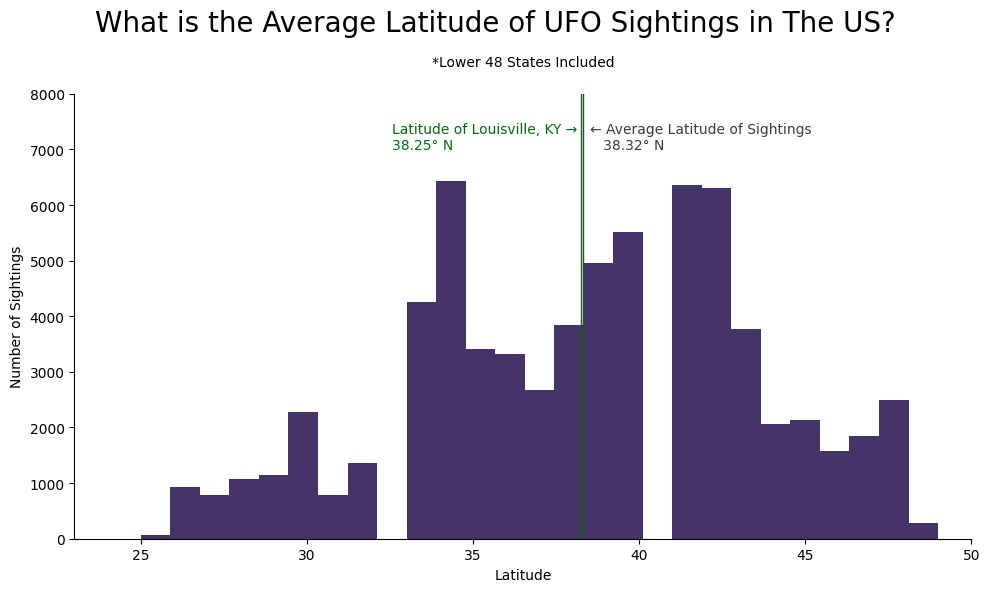

In [ ]:
# latitude cleaning (unchanged)
df["latitude"] = pd.to_numeric(
    df["latitude"].astype(str).str.replace(r".*/.*", "", regex=True),
    errors="coerce"
)

# rounded_lat for lower 48 (unchanged)
df["rounded_lat"] = df["latitude"].where(
    (df["country"].str.lower() == "us") & 
    (df["latitude"].between(24, 50))
).round(0)

mean_latitude = df["latitude"].where(
    (df["country"].str.lower() == "us") & 
    (df["latitude"].between(24, 50))
).mean().round(2)

louisville_latitude = 38.25

plt.figure(figsize=(10,6))

# True histogram (only non-NaN US lower-48 latitudes)
plt.hist(df['rounded_lat'].dropna(), 
         bins=27,                    
         color="#170141", 
         alpha=0.8)

plt.xlabel("Latitude")
plt.ylabel("Number of Sightings")
plt.suptitle("What is the Average Latitude of UFO Sightings in The US?", fontsize=20)
plt.title("*Lower 48 States Included", fontsize=10, pad=20)

ax = plt.gca()
ax.axvline(mean_latitude, linewidth=1, color="#3a3b45")
ax.text(mean_latitude + 0.2, 7000,
        f"← Average Latitude of Sightings\n   {mean_latitude}° N",
        color="#3a3b45")

ax.axvline(louisville_latitude, linewidth=1, color="#006c0e")
ax.text(louisville_latitude - 5.7, 7000,
        f"Latitude of Louisville, KY →\n{louisville_latitude}° N",
        color="#006c0e")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.xlim(23, 50)
plt.ylim(0, 8000)

plt.tight_layout()
plt.show()

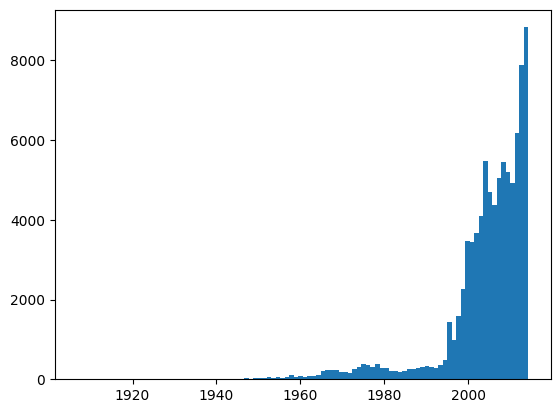

In [ ]:
df['datetime'] = pd.to_datetime(df['datetime'].astype(str), errors="coerce")

df['datetime'].describe()

plt.hist(df['datetime'], bins=100)
plt.show()

In [ ]:
# Group by shape
shapes = df.groupby('shape')

# Total sightings per shape
shape_totals = shapes.size()

# Average sighting datetime per shape
shapes_avg_year = shapes['datetime'].mean()

# Combine both into one DataFrame
shapes_avg_year_totals_df = pd.concat([shapes_avg_year, shape_totals], axis=1)


shapes_avg_year_totals_df


 


,datetime,0
shape,,
changed,1996-06-24 00:30:00.000000,1
changing,2005-08-24 13:52:04.938505,2140
chevron,2003-07-22 04:21:44.475524,1007
cigar,2000-04-05 04:03:21.197278,2241
circle,2005-03-18 07:35:28.558072,8453
cone,2004-12-26 22:58:12.657534,367
crescent,1997-07-24 22:25:30.000000,2
cross,2006-06-17 10:57:22.900763,265
cylinder,2003-08-20 08:24:27.308823,1382


In [ ]:
print(df['shape'].unique())

<StringArray>
[ 'cylinder',     'light',    'circle',    'sphere',      'disk',  'fireball',
   'unknown',      'oval',     'other',     'cigar', 'rectangle',   'chevron',
  'triangle', 'formation',         nan,     'delta',  'changing',       'egg',
     'flash',   'diamond',     'cross',  'teardrop',      'cone',   'pyramid',
     'round',  'crescent',     'flare',   'hexagon',      'dome',   'changed']
Length: 30, dtype: str


# Distribution of Shape Sightings Over Time

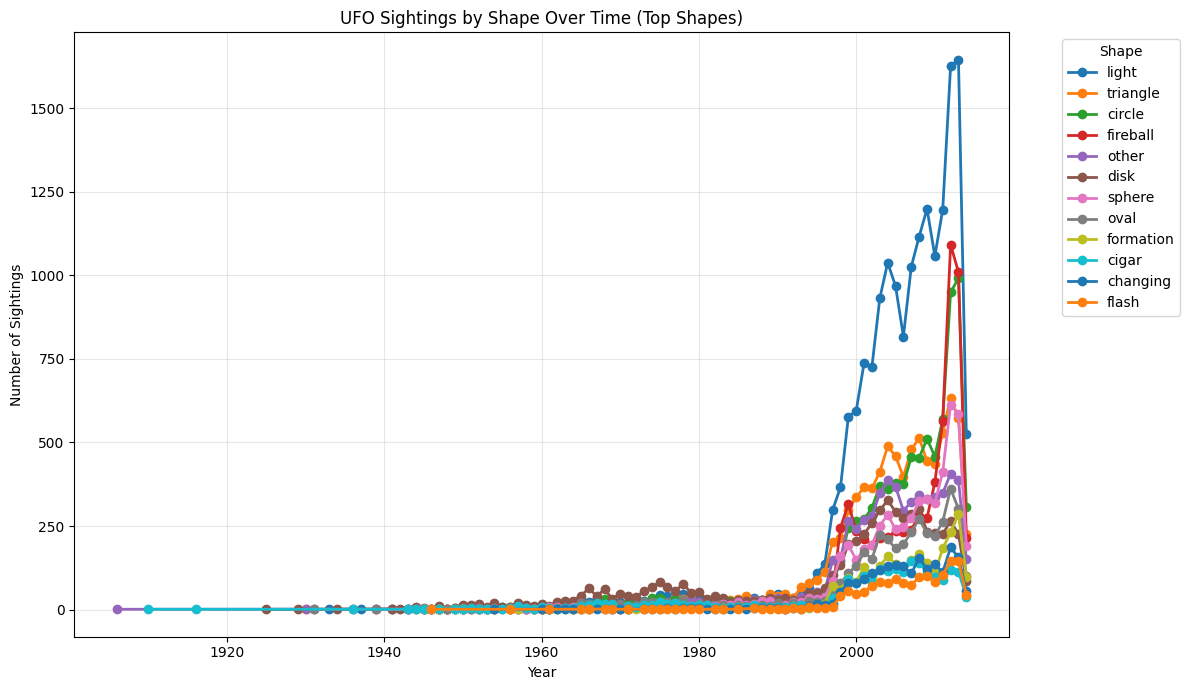

In [ ]:
# Extract year
df['year'] = df['datetime'].astype(str).str[:4].astype(float)


# Count sightings per shape per year
shape_year = df.groupby(['shape', 'year']).size().reset_index(name='count')

plt.figure(figsize=(12, 7))

# Top shapes excluding 'unknown'
top_shapes = (df['shape']
              .value_counts()
              .drop('unknown', errors='ignore')   # safely drop unknown
              .head(12)
              .index)

df_top = shape_year[shape_year['shape'].isin(top_shapes)]

# Plot each shape as a separate line
for shape in top_shapes:
    data = df_top[df_top['shape'] == shape]
    plt.plot(data['year'], data['count'], 
             marker="o", 
             linestyle="-", 
             linewidth=2,
             label=shape)

plt.xlabel("Year")
plt.ylabel("Number of Sightings")
plt.title("UFO Sightings by Shape Over Time (Top Shapes)")
plt.legend(title="Shape", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

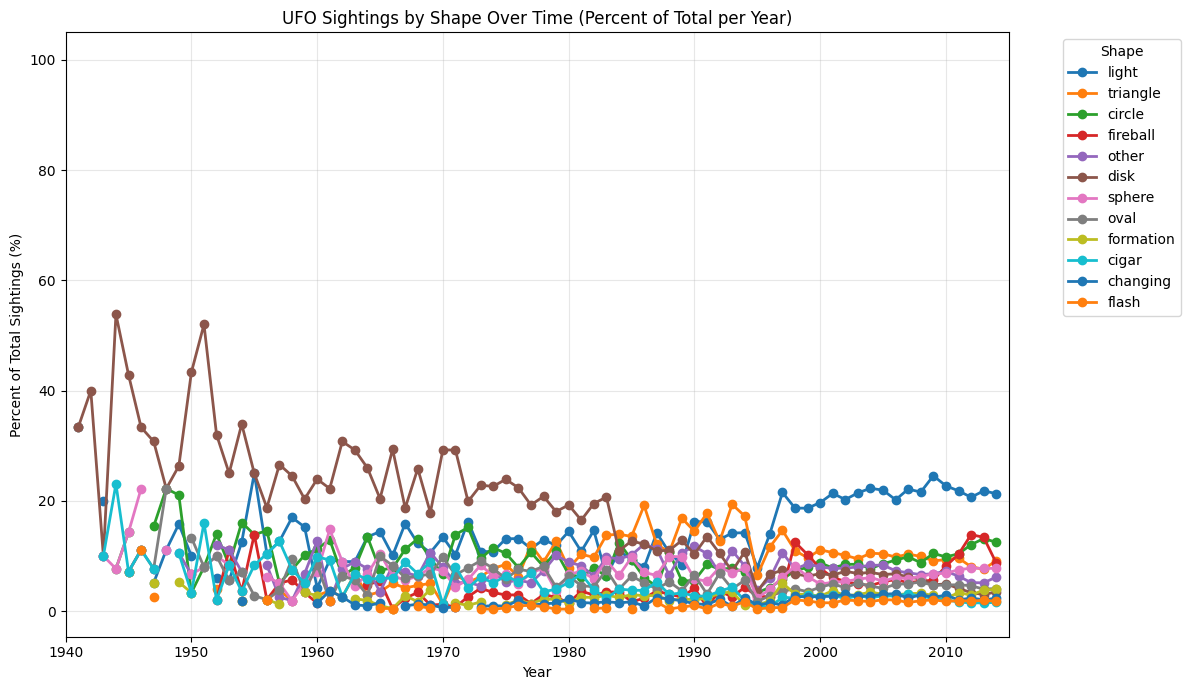

In [ ]:
# Shape as a % of Sightings in Each Year
# Include Top Shapes Only

# Extract year
df['year'] = df['datetime'].astype(str).str[:4].astype(float)

# Total Sightings Per Year
year_totals = df.groupby('year').size()

# Count sightings per shape per year
shape_year = df.groupby(['shape', 'year']).size().reset_index(name='count')

plt.figure(figsize=(12, 7))

# Top shapes excluding 'unknown'
top_shapes = (df['shape']
              .value_counts()
              .drop('unknown', errors='ignore')
              .head(12)
              .index)

df_top = shape_year[shape_year['shape'].isin(top_shapes)]

# Plot each shape as a separate line (as % of total that year)
for shape in top_shapes:
    data = df_top[df_top['shape'] == shape].set_index('year')
    percent = (data['count'] / year_totals * 100)
    plt.plot(percent.index, percent.values, 
             marker="o", 
             linestyle="-", 
             linewidth=2,
             label=shape)

plt.xlabel("Year")
plt.ylabel("Percent of Total Sightings (%)")
plt.title("UFO Sightings by Shape Over Time (Percent of Total per Year)")
plt.legend(title="Shape", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)

plt.xlim(1940, 2015)


plt.tight_layout()
plt.show()

# organize by type of shape 

In [ ]:
# find unique shapes 

print(df['shape'].unique().dropna())

<StringArray>
[ 'cylinder',     'light',    'circle',    'sphere',      'disk',  'fireball',
   'unknown',      'oval',     'other',     'cigar', 'rectangle',   'chevron',
  'triangle', 'formation',     'delta',  'changing',       'egg',     'flash',
   'diamond',     'cross',  'teardrop',      'cone',   'pyramid',     'round',
  'crescent',     'flare',   'hexagon',      'dome',   'changed']
Length: 29, dtype: str


In [ ]:
# group shapes by types 

shape_groups = {
    'circle': 'round', 'sphere': 'round', 'disk': 'round', 
    'oval': 'round', 'round': 'round', 'crescent': 'round', 'dome': 'round',
    
    'triangle': 'triangle', 'delta': 'triangle', 'chevron': 'triangle', 
    'pyramid': 'triangle', 'diamond': 'triangle',
    
    'cylinder': 'cigar', 'cigar': 'cigar',
    
    'light': 'light', 'fireball': 'light', 'flash': 'light', 'flare': 'light',
    
    'changing': 'changing', 'changed': 'changing', 'formation': 'changing',
    'egg': 'changing', 'teardrop': 'changing', 'cone': 'changing',
    'cross': 'changing', 'hexagon': 'changing', 'rectangle': 'changing',
    
    'other': 'other'
}

df['shape_group'] = df['shape'].map(shape_groups)

df['shape_group'].value_counts()


shape_group
light       25907
round       24337
triangle    10813
changing     8511
other        6247
cigar        3623
Name: count, dtype: int64